In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import glob
import json
import copy
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, f1_score, classification_report

# =========================================================
# CONFIG
# =========================================================
DATA_DIR = "/content/drive/MyDrive/processed_meg_regression"

BATCH_SIZE = 8
EPOCHS = 100
LR = 1e-4
WEIGHT_DECAY = 1e-4
RUN_SEED = 42

WINDOW_SIZE = 2048
WINDOW_STRIDE = 1024

EARLY_STOPPING_PATIENCE = 12
MIN_DELTA = 1e-4

# ---------------------------------------------------------
# IMPORTANT: keep filtering OFF first
# ---------------------------------------------------------
ENABLE_WINDOW_FILTER = False
WINDOW_STD_THRESHOLD = 1e-3

# ---------------------------------------------------------
# MODEL / LOSS SETTINGS
# ---------------------------------------------------------
WINDOW_FEATURE_DIM = 128
DROPOUT = 0.25

LAMBDA_BCE = 1.0
LAMBDA_SOFTF1 = 0.2

# ---------------------------------------------------------
# THRESHOLD SEARCH
# ---------------------------------------------------------
THRESHOLD_MIN = 0.40
THRESHOLD_MAX = 0.60
THRESHOLD_STEP = 0.01

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(RUN_SEED)
np.random.seed(RUN_SEED)
random.seed(RUN_SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# =========================================================
# JSON HELPER
# =========================================================
def to_python(obj):
    if isinstance(obj, dict):
        return {k: to_python(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [to_python(v) for v in obj]
    elif isinstance(obj, tuple):
        return [to_python(v) for v in obj]
    elif isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    else:
        return obj


# =========================================================
# WINDOWING
# =========================================================
def is_valid_window(window, std_threshold=1e-3):
    return np.std(window) > std_threshold


def extract_windows_from_trial(
    trial_x,
    trial_y,
    window_size=2048,
    stride=1024,
    enable_filter=False,
    std_threshold=1e-3
):
    """
    trial_x: [C, T]
    trial_y: [2]
    """
    c, t = trial_x.shape
    xs = []
    start = 0

    while start + window_size <= t:
        w = trial_x[:, start:start + window_size]

        if (not enable_filter) or is_valid_window(w, std_threshold=std_threshold):
            xs.append(w)

        start += stride

    if len(xs) == 0:
        return None, None

    return np.stack(xs).astype(np.float32), np.array(trial_y, dtype=np.float32)


# =========================================================
# LOADING
# =========================================================
def extract_subject_id_from_path(x_path):
    base = os.path.basename(x_path)
    return base.split("_")[0]


def load_all_trials_with_subjects(data_dir):
    x_paths = sorted(glob.glob(os.path.join(data_dir, "*_X.npy")))
    print(f"Searching in: {data_dir}")
    print(f"Found {len(x_paths)} X files")

    seq_x_list, y_list, subject_list = [], [], []

    for x_path in x_paths:
        y_path = x_path.replace("_X.npy", "_y.npy")
        if not os.path.exists(y_path):
            print(f"[WARN] Missing y file for: {x_path}")
            continue

        subject_id = extract_subject_id_from_path(x_path)
        X = np.load(x_path)
        y = np.load(y_path)

        n = min(len(X), len(y))
        X, y = X[:n], y[:n]

        for i in range(n):
            seq_x, y_trial = extract_windows_from_trial(
                X[i],
                y[i],
                window_size=WINDOW_SIZE,
                stride=WINDOW_STRIDE,
                enable_filter=ENABLE_WINDOW_FILTER,
                std_threshold=WINDOW_STD_THRESHOLD
            )
            if seq_x is not None:
                seq_x_list.append(seq_x)
                y_list.append(y_trial)
                subject_list.append(subject_id)

    print(f"Total usable trial sequences: {len(seq_x_list)}")
    print(f"Total unique subjects: {len(set(subject_list))}")
    return seq_x_list, y_list, subject_list


def filter_by_subjects(seq_x_list, y_list, subject_list, allowed_subjects):
    out_x, out_y = [], []
    for x, y, s in zip(seq_x_list, y_list, subject_list):
        if s in allowed_subjects:
            out_x.append(x)
            out_y.append(y)
    return out_x, out_y


# =========================================================
# LABEL CONVERSION
# =========================================================
def compute_train_thresholds(train_y_list):
    Y_train = np.stack(train_y_list, axis=0)
    valence_thresh = np.median(Y_train[:, 0])
    arousal_thresh = np.median(Y_train[:, 1])
    return float(valence_thresh), float(arousal_thresh)


def make_binary_labels_from_threshold(y_list, valence_thresh, arousal_thresh):
    Y = np.stack(y_list, axis=0)
    valence_labels = (Y[:, 0] >= valence_thresh).astype(np.int64)
    arousal_labels = (Y[:, 1] >= arousal_thresh).astype(np.int64)
    return valence_labels, arousal_labels


# =========================================================
# DATASET
# =========================================================
class TrialClassificationDataset(Dataset):
    def __init__(self, seq_x_list, labels):
        self.seq_x_list = seq_x_list
        self.labels = labels.astype(np.int64)

    def __len__(self):
        return len(self.seq_x_list)

    def __getitem__(self, idx):
        x_seq = torch.tensor(self.seq_x_list[idx], dtype=torch.float32)  # [W, C, T]
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x_seq, y


# =========================================================
# CUSTOM COLLATE
# =========================================================
def pad_collate_fn(batch):
    x_list, y_list = zip(*batch)

    max_w = max(x.shape[0] for x in x_list)
    c = x_list[0].shape[1]
    t = x_list[0].shape[2]
    batch_size = len(x_list)

    x_padded = torch.zeros(batch_size, max_w, c, t, dtype=torch.float32)
    mask = torch.zeros(batch_size, max_w, dtype=torch.float32)

    for i, x in enumerate(x_list):
        w = x.shape[0]
        x_padded[i, :w] = x
        mask[i, :w] = 1.0

    y = torch.stack(y_list)
    return x_padded, mask, y


# =========================================================
# NORMALIZATION
# =========================================================
def compute_train_stats(dataset_subset):
    xs = []

    for x_seq, _ in dataset_subset:
        xs.append(x_seq.numpy())

    X = np.concatenate(xs, axis=0)  # [all_windows, C, T]

    x_mean = X.mean(axis=(0, 2), keepdims=True)
    x_std = X.std(axis=(0, 2), keepdims=True) + 1e-6

    return x_mean.astype(np.float32), x_std.astype(np.float32)


class NormalizedClassificationDataset(Dataset):
    def __init__(self, base_dataset, x_mean, x_std):
        self.base_dataset = base_dataset
        self.x_mean = torch.tensor(x_mean, dtype=torch.float32)
        self.x_std = torch.tensor(x_std, dtype=torch.float32)

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        x_seq, y = self.base_dataset[idx]  # [W, C, T]

        x_seq = (x_seq - self.x_mean) / self.x_std
        x_seq = x_seq - x_seq.mean(dim=-1, keepdim=True)
        x_seq = x_seq / (x_seq.std(dim=-1, keepdim=True) + 1e-6)
        x_seq = x_seq / (x_seq.abs().max(dim=-1, keepdim=True)[0] + 1e-6)

        return x_seq, y


# =========================================================
# MODEL
# =========================================================
class SEBlock1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, hidden),
            nn.ReLU(),
            nn.Linear(hidden, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        # x: [B, C, T]
        b, c, _ = x.shape
        w = self.pool(x).view(b, c)
        w = self.fc(w).view(b, c, 1)
        return x * w


class ConvBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1, dropout=0.2):
        super().__init__()
        padding = ((kernel_size - 1) // 2) * dilation
        self.block = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=kernel_size, padding=padding, dilation=dilation),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.block(x)


class MultiScaleWindowEncoder(nn.Module):
    def __init__(self, in_channels=143, hidden=128, dropout=0.2):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.branch_k3 = ConvBlock1D(64, hidden, kernel_size=3, dilation=1, dropout=dropout)
        self.branch_k7 = ConvBlock1D(64, hidden, kernel_size=7, dilation=1, dropout=dropout)
        self.branch_dil = ConvBlock1D(64, hidden, kernel_size=5, dilation=2, dropout=dropout)

        self.fuse = nn.Sequential(
            nn.Conv1d(hidden * 3, hidden, kernel_size=1),
            nn.BatchNorm1d(hidden),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.se = SEBlock1D(hidden, reduction=8)

        self.temporal_refine = nn.Sequential(
            ConvBlock1D(hidden, hidden, kernel_size=5, dilation=1, dropout=dropout),
            ConvBlock1D(hidden, hidden, kernel_size=5, dilation=2, dropout=dropout),
        )

        self.out_pool = nn.AdaptiveAvgPool1d(1)

    def forward(self, x):
        """
        x: [B*W, C, T]
        returns: [B*W, hidden]
        """
        x = self.stem(x)

        b1 = self.branch_k3(x)
        b2 = self.branch_k7(x)
        b3 = self.branch_dil(x)

        z = torch.cat([b1, b2, b3], dim=1)
        z = self.fuse(z)
        z = self.se(z)
        z = self.temporal_refine(z)

        z = self.out_pool(z).squeeze(-1)
        return z


class GatedWindowPooling(nn.Module):
    def __init__(self, dim, hidden=128, dropout=0.2):
        super().__init__()
        self.gate = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1)
        )

    def forward(self, z, mask=None):
        """
        z: [B, W, D]
        mask: [B, W]
        """
        scores = self.gate(z)  # [B, W, 1]

        if mask is not None:
            scores = scores.masked_fill(mask.unsqueeze(-1) == 0, -1e9)

        weights = torch.softmax(scores, dim=1)
        pooled = torch.sum(weights * z, dim=1)
        return pooled, weights


class MultiScaleCNNGatedPoolClassifier(nn.Module):
    def __init__(
        self,
        in_channels=143,
        window_feature_dim=128,
        dropout=0.25
    ):
        super().__init__()

        self.window_encoder = MultiScaleWindowEncoder(
            in_channels=in_channels,
            hidden=window_feature_dim,
            dropout=dropout
        )

        self.gated_pool = GatedWindowPooling(
            dim=window_feature_dim,
            hidden=128,
            dropout=dropout
        )

        self.head = nn.Sequential(
            nn.Linear(window_feature_dim * 2, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x_seq, mask=None, return_attention=False):
        """
        x_seq: [B, W, C, T]
        mask:  [B, W]
        """
        B, W, C, T = x_seq.shape

        x = x_seq.reshape(B * W, C, T)
        z = self.window_encoder(x)      # [B*W, D]
        z = z.reshape(B, W, -1)         # [B, W, D]

        if mask is None:
            mask = torch.ones(B, W, device=x_seq.device)

        mask_exp = mask.unsqueeze(-1)

        # masked mean pooling
        z_sum = (z * mask_exp).sum(dim=1)
        z_count = mask_exp.sum(dim=1).clamp(min=1e-6)
        z_mean = z_sum / z_count

        # gated pooling
        z_gate, attn = self.gated_pool(z, mask=mask)

        z_final = torch.cat([z_mean, z_gate], dim=1)
        logits = self.head(z_final).squeeze(-1)   # [B]

        if return_attention:
            return logits, attn
        return logits


# =========================================================
# LOSS
# =========================================================
class BCEWithSoftF1Loss(nn.Module):
    def __init__(self, pos_weight=None, lambda_bce=1.0, lambda_softf1=0.2, eps=1e-8):
        super().__init__()
        self.lambda_bce = lambda_bce
        self.lambda_softf1 = lambda_softf1
        self.eps = eps
        self.pos_weight = pos_weight

    def forward(self, logits, targets):
        targets = targets.float()

        if self.pos_weight is not None:
            bce = F.binary_cross_entropy_with_logits(
                logits, targets, pos_weight=self.pos_weight
            )
        else:
            bce = F.binary_cross_entropy_with_logits(logits, targets)

        probs = torch.sigmoid(logits)

        tp = torch.sum(probs * targets)
        fp = torch.sum(probs * (1.0 - targets))
        fn = torch.sum((1.0 - probs) * targets)

        soft_f1 = (2.0 * tp + self.eps) / (2.0 * tp + fp + fn + self.eps)
        soft_f1_loss = 1.0 - soft_f1

        return self.lambda_bce * bce + self.lambda_softf1 * soft_f1_loss


# =========================================================
# METRICS
# =========================================================
def compute_classification_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="binary", zero_division=0)
    return acc, f1


def find_best_threshold(y_true, y_prob, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(THRESHOLD_MIN, THRESHOLD_MAX + 1e-9, THRESHOLD_STEP)

    best_threshold = 0.5
    best_f1 = -1.0

    for th in thresholds:
        y_pred = (y_prob >= th).astype(np.int64)
        f1 = f1_score(y_true, y_pred, average="binary", zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = th

    return float(best_threshold), float(best_f1)


# =========================================================
# TRAIN / EVAL
# =========================================================
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0

    for x_seq, mask, y in loader:
        x_seq = x_seq.to(DEVICE)
        mask = mask.to(DEVICE)
        y = y.to(DEVICE).float()

        logits = model(x_seq, mask=mask)
        loss = criterion(logits, y)

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()

    return {"loss": total_loss / len(loader)}


@torch.no_grad()
def collect_probs(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_true = []
    all_prob = []

    for x_seq, mask, y in loader:
        x_seq = x_seq.to(DEVICE)
        mask = mask.to(DEVICE)
        y = y.to(DEVICE).float()

        logits = model(x_seq, mask=mask)
        loss = criterion(logits, y)
        total_loss += loss.item()

        prob_pos = torch.sigmoid(logits)

        all_true.append(y.cpu().numpy())
        all_prob.append(prob_pos.cpu().numpy())

    y_true = np.concatenate(all_true).astype(np.int64)
    y_prob = np.concatenate(all_prob)

    return {
        "loss": total_loss / len(loader),
        "y_true": y_true,
        "y_prob": y_prob,
    }


@torch.no_grad()
def evaluate_with_threshold(model, loader, criterion, threshold=0.5):
    model.eval()
    total_loss = 0.0
    all_true = []
    all_prob = []

    for x_seq, mask, y in loader:
        x_seq = x_seq.to(DEVICE)
        mask = mask.to(DEVICE)
        y = y.to(DEVICE).float()

        logits = model(x_seq, mask=mask)
        loss = criterion(logits, y)
        total_loss += loss.item()

        prob_pos = torch.sigmoid(logits)

        all_true.append(y.cpu().numpy())
        all_prob.append(prob_pos.cpu().numpy())

    y_true = np.concatenate(all_true).astype(np.int64)
    y_prob = np.concatenate(all_prob)
    y_pred = (y_prob >= threshold).astype(np.int64)

    acc, f1 = compute_classification_metrics(y_true, y_pred)

    return {
        "loss": total_loss / len(loader),
        "accuracy": acc,
        "f1": f1,
        "y_true": y_true,
        "y_prob": y_prob,
        "y_pred": y_pred,
        "threshold": threshold,
    }


# =========================================================
# CURVE PLOTTING
# =========================================================
def save_fold_curves(history, held_out_subject):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"MultiScaleCNN Loss - Held-out {held_out_subject}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"curve_loss_multiscale_valence_{held_out_subject}.png")
    plt.close()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["val_acc"], label="Val Accuracy")
    plt.plot(epochs, history["val_f1"], label="Val F1")
    plt.xlabel("Epoch")
    plt.ylabel("Metric")
    plt.title(f"MultiScaleCNN Metrics - Held-out {held_out_subject}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"curve_metrics_multiscale_valence_{held_out_subject}.png")
    plt.close()


# =========================================================
# TRAIN ONE LOSO FOLD FOR VALENCE
# =========================================================
def train_one_loso_fold_valence(held_out_subject, seq_x_list, y_list, subject_list):
    train_subjects = sorted(list(set(subject_list) - {held_out_subject}))
    val_subjects = [held_out_subject]

    train_x, train_y_raw = filter_by_subjects(seq_x_list, y_list, subject_list, set(train_subjects))
    val_x, val_y_raw = filter_by_subjects(seq_x_list, y_list, subject_list, set(val_subjects))

    valence_thresh, arousal_thresh = compute_train_thresholds(train_y_raw)

    train_valence_labels, _ = make_binary_labels_from_threshold(
        train_y_raw, valence_thresh, arousal_thresh
    )
    val_valence_labels, _ = make_binary_labels_from_threshold(
        val_y_raw, valence_thresh, arousal_thresh
    )

    print("\n" + "=" * 70)
    print(f"LOSO FOLD | Held-out subject: {held_out_subject} | Task: valence")
    print("=" * 70)
    print(f"Train trials: {len(train_x)}")
    print(f"Val trials:   {len(val_x)}")
    print(f"Train threshold valence (median): {valence_thresh:.4f}")
    print(f"Train class counts: {np.bincount(train_valence_labels, minlength=2)}")
    print(f"Val class counts:   {np.bincount(val_valence_labels, minlength=2)}")

    train_base = TrialClassificationDataset(train_x, train_valence_labels)
    val_base = TrialClassificationDataset(val_x, val_valence_labels)

    x_mean, x_std = compute_train_stats(train_base)

    train_set = NormalizedClassificationDataset(train_base, x_mean, x_std)
    val_set = NormalizedClassificationDataset(val_base, x_mean, x_std)

    train_loader = DataLoader(
        train_set,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0,
        pin_memory=True,
        collate_fn=pad_collate_fn
    )
    val_loader = DataLoader(
        val_set,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=True,
        collate_fn=pad_collate_fn
    )

    model = MultiScaleCNNGatedPoolClassifier(
        in_channels=143,
        window_feature_dim=WINDOW_FEATURE_DIM,
        dropout=DROPOUT
    ).to(DEVICE)

    class_counts = np.bincount(train_valence_labels, minlength=2).astype(np.float32)
    neg_count, pos_count = class_counts[0], class_counts[1]
    pos_weight = torch.tensor(neg_count / max(pos_count, 1.0), dtype=torch.float32, device=DEVICE)

    criterion = BCEWithSoftF1Loss(
        pos_weight=pos_weight,
        lambda_bce=LAMBDA_BCE,
        lambda_softf1=LAMBDA_SOFTF1
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=4
    )

    best_score = -float("inf")
    best_epoch = -1
    best_checkpoint = None
    epochs_without_improvement = 0

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_acc": [],
        "val_f1": [],
        "best_threshold": [],
    }

    for epoch in range(1, EPOCHS + 1):
        train_metrics = train_one_epoch(model, train_loader, optimizer, criterion)

        train_prob_dict = collect_probs(model, train_loader, criterion)
        best_threshold, train_best_f1 = find_best_threshold(
            train_prob_dict["y_true"],
            train_prob_dict["y_prob"]
        )

        val_metrics = evaluate_with_threshold(
            model,
            val_loader,
            criterion,
            threshold=best_threshold
        )

        score = val_metrics["f1"]
        scheduler.step(score)

        history["train_loss"].append(train_metrics["loss"])
        history["val_loss"].append(val_metrics["loss"])
        history["val_acc"].append(val_metrics["accuracy"])
        history["val_f1"].append(val_metrics["f1"])
        history["best_threshold"].append(best_threshold)

        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"Held-out {held_out_subject} | valence | Epoch {epoch:03d} | "
            f"LR: {current_lr:.6f} | "
            f"Train Loss: {train_metrics['loss']:.4f} | "
            f"Train BestThr: {best_threshold:.2f} | "
            f"Train BestF1: {train_best_f1:.4f} | "
            f"Val Loss: {val_metrics['loss']:.4f} | "
            f"Val Acc: {val_metrics['accuracy']:.4f} | "
            f"Val F1: {val_metrics['f1']:.4f}"
        )

        improved = score > (best_score + MIN_DELTA)

        if improved:
            best_score = score
            best_epoch = epoch
            epochs_without_improvement = 0

            best_checkpoint = {
                "held_out_subject": held_out_subject,
                "epoch": epoch,
                "score": score,
                "accuracy": val_metrics["accuracy"],
                "f1": val_metrics["f1"],
                "y_true": val_metrics["y_true"],
                "y_prob": val_metrics["y_prob"],
                "y_pred": val_metrics["y_pred"],
                "valence_thresh": valence_thresh,
                "decision_threshold": best_threshold,
            }

            torch.save(
                {
                    "held_out_subject": held_out_subject,
                    "task_name": "valence",
                    "epoch": epoch,
                    "model_state_dict": copy.deepcopy(model.state_dict()),
                    "accuracy": val_metrics["accuracy"],
                    "f1": val_metrics["f1"],
                    "valence_thresh": valence_thresh,
                    "decision_threshold": best_threshold,
                    "loss_name": "BCEWithSoftF1Loss",
                    "lambda_bce": LAMBDA_BCE,
                    "lambda_softf1": LAMBDA_SOFTF1,
                },
                f"best_model_multiscale_valence_{held_out_subject}.pt"
            )

            print(
                f"🔥 Best fold updated | "
                f"Epoch {epoch} | "
                f"Thr: {best_threshold:.2f} | "
                f"Acc: {val_metrics['accuracy']:.4f} | "
                f"F1: {val_metrics['f1']:.4f}"
            )
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            print(
                f"Early stopping for held-out {held_out_subject} at epoch {epoch}. "
                f"Best epoch was {best_epoch}."
            )
            break

    if best_checkpoint is None:
        raise RuntimeError(f"No best checkpoint saved for held-out subject {held_out_subject}")

    np.save(f"best_y_true_multiscale_valence_{held_out_subject}.npy", best_checkpoint["y_true"])
    np.save(f"best_y_prob_multiscale_valence_{held_out_subject}.npy", best_checkpoint["y_prob"])
    np.save(f"best_y_pred_multiscale_valence_{held_out_subject}.npy", best_checkpoint["y_pred"])

    save_fold_curves(history, held_out_subject)

    with open(f"history_multiscale_valence_{held_out_subject}.json", "w") as f:
        json.dump(to_python(history), f, indent=4)

    print("\nClassification report:")
    print(classification_report(best_checkpoint["y_true"], best_checkpoint["y_pred"], digits=4, zero_division=0))

    return {
        "held_out_subject": held_out_subject,
        "best_epoch": best_checkpoint["epoch"],
        "accuracy": best_checkpoint["accuracy"],
        "f1": best_checkpoint["f1"],
        "valence_thresh": best_checkpoint["valence_thresh"],
        "decision_threshold": best_checkpoint["decision_threshold"],
    }


# =========================================================
# RUN VALENCE ACROSS ALL SUBJECTS
# =========================================================
def run_loso_valence(seq_x_list, y_list, subject_list):
    unique_subjects = sorted(list(set(subject_list)))
    print(f"\nRunning LOSO binary classification for valence across {len(unique_subjects)} subjects:")
    print(unique_subjects)

    all_fold_results = []

    for held_out_subject in unique_subjects:
        fold_result = train_one_loso_fold_valence(
            held_out_subject,
            seq_x_list,
            y_list,
            subject_list
        )
        all_fold_results.append(fold_result)

    accs = np.array([r["accuracy"] for r in all_fold_results], dtype=np.float32)
    f1s = np.array([r["f1"] for r in all_fold_results], dtype=np.float32)
    thresholds = np.array([r["decision_threshold"] for r in all_fold_results], dtype=np.float32)

    summary = {
        "task_name": "valence",
        "accuracy_mean": float(accs.mean()),
        "accuracy_std": float(accs.std()),
        "f1_mean": float(f1s.mean()),
        "f1_std": float(f1s.std()),
        "decision_threshold_mean": float(thresholds.mean()),
        "decision_threshold_std": float(thresholds.std()),
        "per_subject": all_fold_results,
    }

    with open("multiscale_valence_summary.json", "w") as f:
        json.dump(to_python(summary), f, indent=4)

    print("\n" + "=" * 70)
    print("MULTISCALE VALENCE FINAL SUMMARY")
    print("=" * 70)
    print(f"Accuracy: {summary['accuracy_mean']:.4f} ± {summary['accuracy_std']:.4f}")
    print(f"F1:       {summary['f1_mean']:.4f} ± {summary['f1_std']:.4f}")
    print(f"Thr:      {summary['decision_threshold_mean']:.4f} ± {summary['decision_threshold_std']:.4f}")

    return summary


# =========================================================
# MAIN
# =========================================================
def main():
    print("Loading processed trials...")
    seq_x_list, y_list, subject_list = load_all_trials_with_subjects(DATA_DIR)

    if len(seq_x_list) == 0:
        raise FileNotFoundError(f"No processed trials found in {DATA_DIR}.")

    print("Example x_seq shape:", seq_x_list[0].shape)
    print("Example y shape:", y_list[0].shape)

    config = {
        "model": "MultiScaleCNNGatedPoolClassifier",
        "window_feature_dim": WINDOW_FEATURE_DIM,
        "dropout": DROPOUT,
        "lr": LR,
        "epochs": EPOCHS,
        "evaluation": "LOSO binary classification for valence",
        "label_strategy": "global train-only threshold per fold",
        "threshold_type": "median",
        "loss": "BCEWithSoftF1Loss",
        "lambda_bce": LAMBDA_BCE,
        "lambda_softf1": LAMBDA_SOFTF1,
        "decision_rule": "train-fold F1-optimized probability threshold",
        "threshold_search_range": [THRESHOLD_MIN, THRESHOLD_MAX, THRESHOLD_STEP],
        "window_filtering": ENABLE_WINDOW_FILTER,
    }

    with open("multiscale_valence_config.json", "w") as f:
        json.dump(to_python(config), f, indent=4)

    summary_valence = run_loso_valence(
        seq_x_list,
        y_list,
        subject_list
    )

    with open("multiscale_valence_final_summary.json", "w") as f:
        json.dump(to_python(summary_valence), f, indent=4)

    print("\nSaved:")
    print("  multiscale_valence_config.json")
    print("  multiscale_valence_summary.json")
    print("  multiscale_valence_final_summary.json")
    print("  best_model_multiscale_valence_<subject>.pt")
    print("  best_y_true_multiscale_valence_<subject>.npy")
    print("  best_y_prob_multiscale_valence_<subject>.npy")
    print("  best_y_pred_multiscale_valence_<subject>.npy")
    print("  history_multiscale_valence_<subject>.json")
    print("  curve_loss_multiscale_valence_<subject>.png")
    print("  curve_metrics_multiscale_valence_<subject>.png")


if __name__ == "__main__":
    main()

Loading processed trials...
Searching in: /content/drive/MyDrive/processed_meg_regression
Found 82 X files
Total usable trial sequences: 814
Total unique subjects: 21
Example x_seq shape: (4, 143, 2048)
Example y shape: (2,)

Running LOSO binary classification for valence across 21 subjects:
['sub-01', 'sub-02', 'sub-03', 'sub-04', 'sub-05', 'sub-06', 'sub-07', 'sub-08', 'sub-09', 'sub-10', 'sub-11', 'sub-14', 'sub-15', 'sub-16', 'sub-17', 'sub-18', 'sub-19', 'sub-20', 'sub-21', 'sub-22', 'sub-23']

LOSO FOLD | Held-out subject: sub-01 | Task: valence
Train trials: 774
Val trials:   40
Train threshold valence (median): 0.5000
Train class counts: [365 409]
Val class counts:   [20 20]
Held-out sub-01 | valence | Epoch 001 | LR: 0.000100 | Train Loss: 0.7513 | Train BestThr: 0.46 | Train BestF1: 0.6963 | Val Loss: 0.7379 | Val Acc: 0.5000 | Val F1: 0.6667
🔥 Best fold updated | Epoch 1 | Thr: 0.46 | Acc: 0.5000 | F1: 0.6667
Held-out sub-01 | valence | Epoch 002 | LR: 0.000100 | Train Loss:

In [3]:
import zipfile
from google.colab import files
import os
import glob

# Define the patterns for the files the user wants to download
file_patterns = [
    'history_multiscale_valence_sub-??.json',
    'curve_loss_multiscale_valence_sub-??.png',
    'curve_metrics_multiscale_valence_sub-??.png',
    'multiscale_valence_config.json',
    'multiscale_valence_summary.json',
    'multiscale_valence_final_summary.json',
    'best_model_multiscale_valence_sub-??.pt',
    'best_y_true_multiscale_valence_sub-??.npy',
    'best_y_prob_multiscale_valence_sub-??.npy',
    'best_y_pred_multiscale_valence_sub-??.npy'
]

# Collect all files matching the patterns in the current directory
files_to_zip = []
for pattern in file_patterns:
    files_to_zip.extend(glob.glob(pattern))

# Define the name of the zip file
zip_filename = 'multiscale_valence_results.zip'

# Create the zip archive
with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for file in files_to_zip:
        if os.path.exists(file):
            zipf.write(file, os.path.basename(file))
        else:
            print(f"[WARN] File not found when zipping: {file}")

print(f"Successfully created {zip_filename} containing {len(files_to_zip)} files.")

# Provide a download link for the zip file
files.download(zip_filename)

Successfully created multiscale_valence_results.zip containing 150 files.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Found 21 subject files
Total samples: 814
Class counts: [385 429]


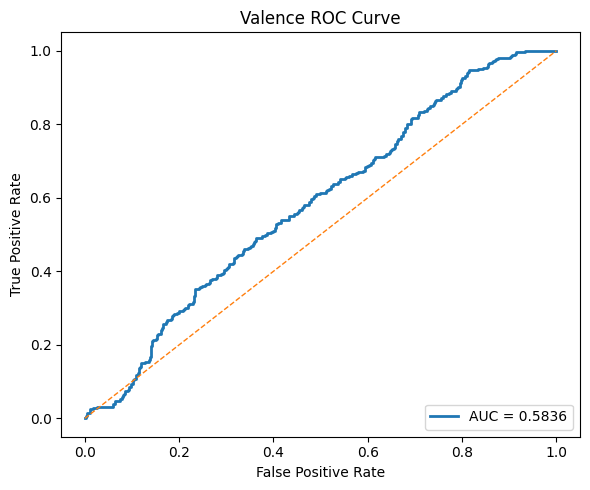

Valence ROC AUC: 0.5836


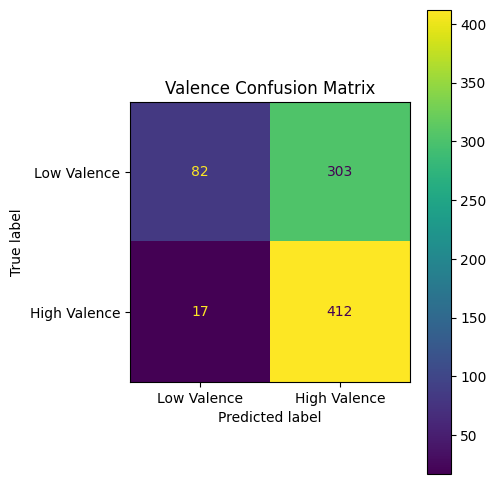

Confusion Matrix:
[[ 82 303]
 [ 17 412]]


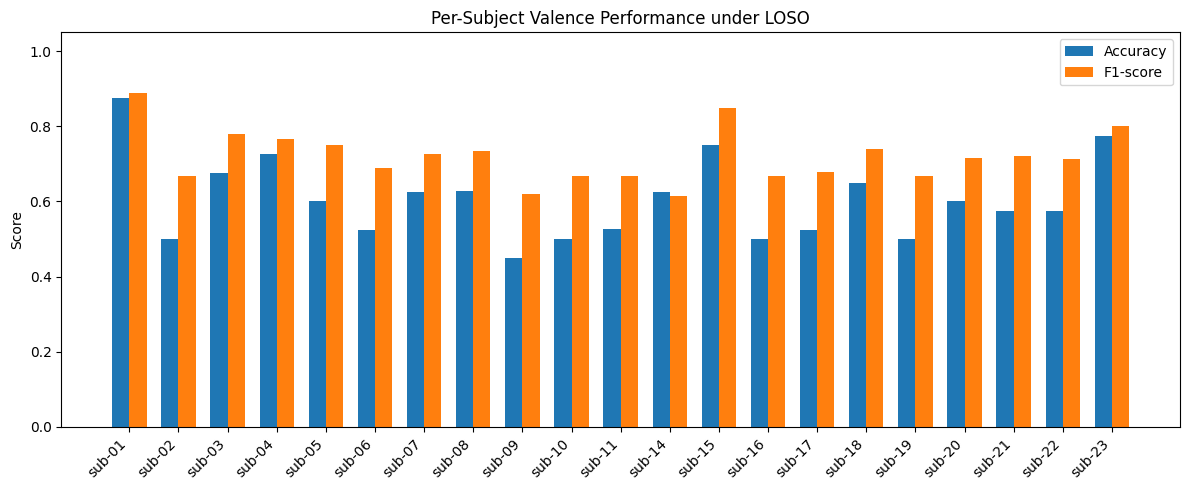


Valence Summary
Accuracy: 0.6050 ± 0.1057
F1-score: 0.7200 ± 0.0678
ROC AUC:  0.5836

Saved figures:
  valence_roc_auc.png
  valence_confusion_matrix.png
  valence_per_subject_accuracy_f1.png


In [4]:
import os
import glob
import json
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

RESULT_DIR = "."
TASK = "multiscale_valence"
SUMMARY_JSON = os.path.join(RESULT_DIR, "multiscale_valence_final_summary.json")

y_true_all, y_prob_all, y_pred_all = [], [], []

true_files = sorted(glob.glob(os.path.join(RESULT_DIR, f"best_y_true_{TASK}_*.npy")))

print(f"Found {len(true_files)} subject files")

for true_path in true_files:
    subject = true_path.replace(os.path.join(RESULT_DIR, f"best_y_true_{TASK}_"), "")
    subject = subject.replace(".npy", "")

    prob_path = os.path.join(RESULT_DIR, f"best_y_prob_{TASK}_{subject}.npy")
    pred_path = os.path.join(RESULT_DIR, f"best_y_pred_{TASK}_{subject}.npy")

    if not os.path.exists(prob_path) or not os.path.exists(pred_path):
        print(f"Skipping {subject}: missing files")
        continue

    y_true_all.append(np.load(true_path))
    y_prob_all.append(np.load(prob_path))
    y_pred_all.append(np.load(pred_path))

y_true_all = np.concatenate(y_true_all).astype(int)
y_prob_all = np.concatenate(y_prob_all)
y_pred_all = np.concatenate(y_pred_all).astype(int)

print("Total samples:", len(y_true_all))
print("Class counts:", np.bincount(y_true_all))

# =========================================================
# ROC + AUC
# =========================================================
fpr, tpr, _ = roc_curve(y_true_all, y_prob_all)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Valence ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("valence_roc_auc.png", dpi=300)
plt.show()

print(f"Valence ROC AUC: {roc_auc:.4f}")

# =========================================================
# CONFUSION MATRIX
# =========================================================
cm = confusion_matrix(y_true_all, y_pred_all)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Low Valence", "High Valence"]
)

fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(values_format="d", ax=ax)
plt.title("Valence Confusion Matrix")
plt.tight_layout()
plt.savefig("valence_confusion_matrix.png", dpi=300)
plt.show()

print("Confusion Matrix:")
print(cm)

# =========================================================
# PER-SUBJECT ACCURACY + F1
# =========================================================
with open(SUMMARY_JSON, "r") as f:
    summary = json.load(f)

per_subject = summary["per_subject"]

subjects = [r["held_out_subject"] for r in per_subject]
accuracies = [r["accuracy"] for r in per_subject]
f1s = [r["f1"] for r in per_subject]

x = np.arange(len(subjects))
width = 0.35

plt.figure(figsize=(12, 5))
plt.bar(x - width / 2, accuracies, width, label="Accuracy")
plt.bar(x + width / 2, f1s, width, label="F1-score")
plt.xticks(x, subjects, rotation=45, ha="right")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.title("Per-Subject Valence Performance under LOSO")
plt.legend()
plt.tight_layout()
plt.savefig("valence_per_subject_accuracy_f1.png", dpi=300)
plt.show()

print("\nValence Summary")
print("=" * 40)
print(f"Accuracy: {summary['accuracy_mean']:.4f} ± {summary['accuracy_std']:.4f}")
print(f"F1-score: {summary['f1_mean']:.4f} ± {summary['f1_std']:.4f}")
print(f"ROC AUC:  {roc_auc:.4f}")

print("\nSaved figures:")
print("  valence_roc_auc.png")
print("  valence_confusion_matrix.png")
print("  valence_per_subject_accuracy_f1.png")